In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\ML project\car_price_prediction.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (19237, 18)

Columns:
['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

Data Types:
ID                    int64
Price                 int64
Levy                 object
Manufacturer         object
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage              object
Cylinders           float64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


In [9]:
df["Mileage"] = df["Mileage"].str.replace(" km", "", regex=False)

df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

In [10]:
df["Levy"] = df["Levy"].replace("-", pd.NA)

df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")

In [11]:
print(df[["Mileage", "Levy"]].head())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

   Mileage    Levy
0   186005  1399.0
1   192000  1018.0
2   200000     NaN
3   168966   862.0
4    91901   446.0

Missing Values After Cleaning:
ID                     0
Price                  0
Levy                5819
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume          0
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64


# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

In [13]:
#  Fill missing Levy values with median
df["Levy"] = df["Levy"].fillna(df["Levy"].median())

print("Missing Levy values after filling:", df["Levy"].isnull().sum())

Missing Levy values after filling: 0


In [14]:
print("Total missing values:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Total missing values:
ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

Total duplicate rows: 0


In [15]:
# Target column
y = df["Price"]

# Input features
X = df[
    [
        "Levy",
        "Manufacturer",
        "Prod. year",
        "Category",
        "Leather interior",
        "Fuel type",
        "Engine volume",
        "Mileage",
        "Cylinders",
        "Gear box type",
        "Drive wheels",
        "Airbags"
    ]
]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (18924, 12)
Target shape: (18924,)


,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Airbags
0,1399.0,LEXUS,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,12
1,1018.0,CHEVROLET,2011,Jeep,No,Petrol,3,192000,6.0,Tiptronic,4x4,8
2,781.0,HONDA,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,2
3,862.0,FORD,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,0
4,446.0,HONDA,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,4


In [16]:
print(X.dtypes)

Levy                float64
Manufacturer         object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage               int64
Cylinders           float64
Gear box type        object
Drive wheels         object
Airbags               int64
dtype: object


In [17]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumeric Columns:")
print(numeric_columns)

Categorical Columns:
['Manufacturer', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Gear box type', 'Drive wheels']

Numeric Columns:
['Levy', 'Prod. year', 'Mileage', 'Cylinders', 'Airbags']


In [18]:
# Engine volume se non-numeric text remove karna
df["Engine volume"] = (
    df["Engine volume"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

# Numeric conversion
df["Engine volume"] = pd.to_numeric(
    df["Engine volume"],
    errors="coerce"
)

print(df["Engine volume"].head())
print("\nData type:", df["Engine volume"].dtype)

0    3.5
1    3.0
2    1.3
3    2.5
4    1.3
Name: Engine volume, dtype: float64

Data type: float64


In [19]:
print("Missing Engine volume values:",
      df["Engine volume"].isnull().sum())

Missing Engine volume values: 0


In [20]:
X = df[
    [
        "Levy",
        "Manufacturer",
        "Prod. year",
        "Category",
        "Leather interior",
        "Fuel type",
        "Engine volume",
        "Mileage",
        "Cylinders",
        "Gear box type",
        "Drive wheels",
        "Airbags"
    ]
]

y = df["Price"]

In [22]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

X_encoded.head()

Original shape: (18924, 12)
Encoded shape: (18924, 92)


,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags,Manufacturer_ALFA ROMEO,Manufacturer_ASTON MARTIN,Manufacturer_AUDI,Manufacturer_BENTLEY,...,Fuel type_Hybrid,Fuel type_Hydrogen,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear
0,1399.0,2010,3.5,186005,6.0,12,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,1018.0,2011,3.0,192000,6.0,8,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
2,781.0,2006,1.3,200000,4.0,2,0,0,0,0,...,0,0,0,1,0,0,0,1,1,0
3,862.0,2011,2.5,168966,4.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,446.0,2014,1.3,91901,4.0,4,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [23]:
print(X_encoded.dtypes)

Levy                       float64
Prod. year                   int64
Engine volume              float64
Mileage                      int64
Cylinders                  float64
                            ...   
Gear box type_Manual         int64
Gear box type_Tiptronic      int64
Gear box type_Variator       int64
Drive wheels_Front           int64
Drive wheels_Rear            int64
Length: 92, dtype: object


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15139, 92)
X_test shape: (3785, 92)
y_train shape: (15139,)
y_test shape: (3785,)


In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [27]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[12726.97769571  5535.42077685 19109.3695349  -2415.36705576
  9411.42755122 26521.72078144 14540.00045327 28048.0528768
 -9742.34895585 16856.09405725]


In [28]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,11604,12726.977696
1,470,5535.420777
2,20162,19109.369535
3,7527,-2415.367056
4,18817,9411.427551
5,44003,26521.720781
6,21326,14540.000453
7,15681,28048.052877
8,6899,-9742.348956
9,1333,16856.094057


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Evaluation:
MAE: 12900.690661697909
MSE: 527292719.5908979
R² Score: -0.5229629124636443


In [30]:
print(df["Price"].describe())

count    1.892400e+04
mean     1.858744e+04
std      1.921356e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.206300e+04
max      2.630750e+07
Name: Price, dtype: float64


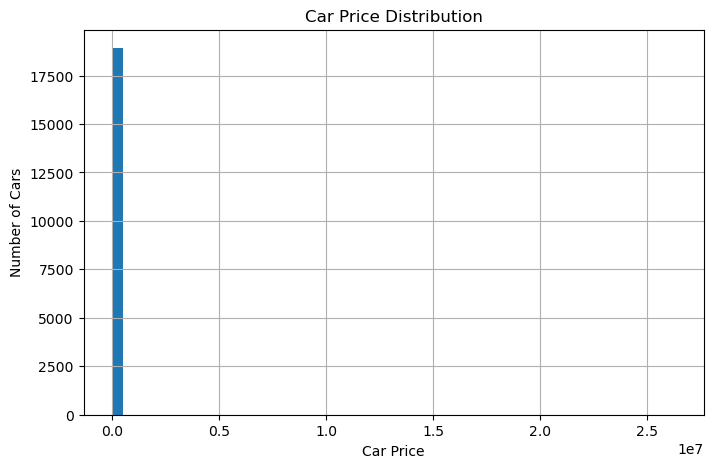

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=50)

plt.xlabel("Car Price")
plt.ylabel("Number of Cars")
plt.title("Car Price Distribution")
plt.grid(True)

plt.show()

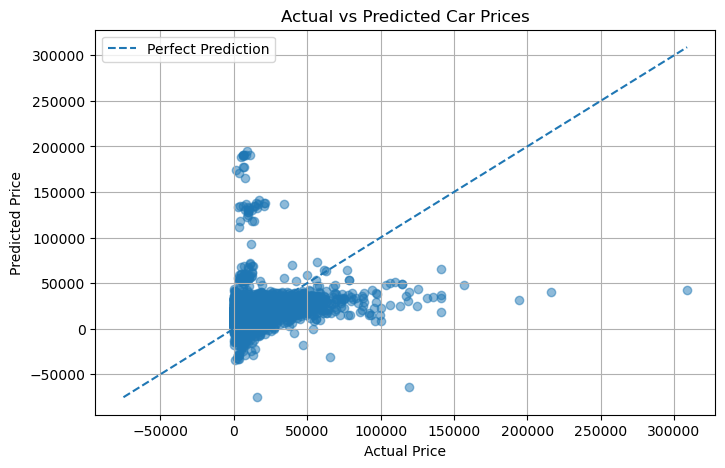

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())

print("\nCars with Price <= 0:")
print((df["Price"] <= 0).sum())

Minimum Price: 1
Maximum Price: 26307500

Cars with Price <= 0:
0


In [34]:
print(df["Price"].quantile([0.01, 0.25, 0.50, 0.75, 0.99]))

0.01       45.0
0.25     5331.0
0.50    13172.0
0.75    22063.0
0.99    84675.0
Name: Price, dtype: float64


In [35]:
df = df[df["Price"] > 0].copy()

print("Shape after removing invalid prices:", df.shape)

Shape after removing invalid prices: (18924, 18)


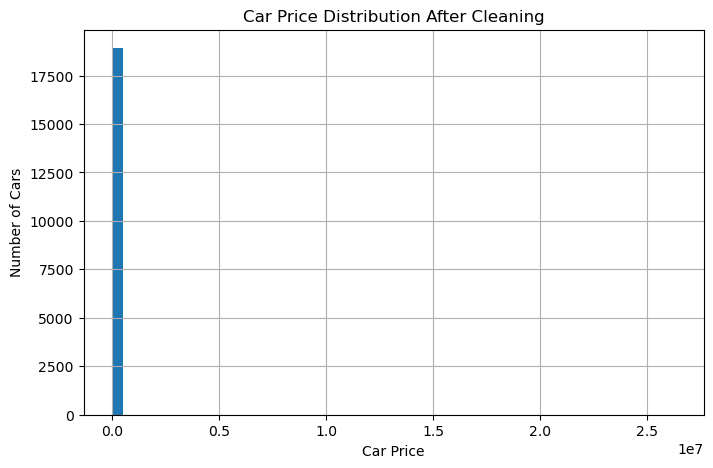

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=50)

plt.xlabel("Car Price")
plt.ylabel("Number of Cars")
plt.title("Car Price Distribution After Cleaning")
plt.grid(True)

plt.show()

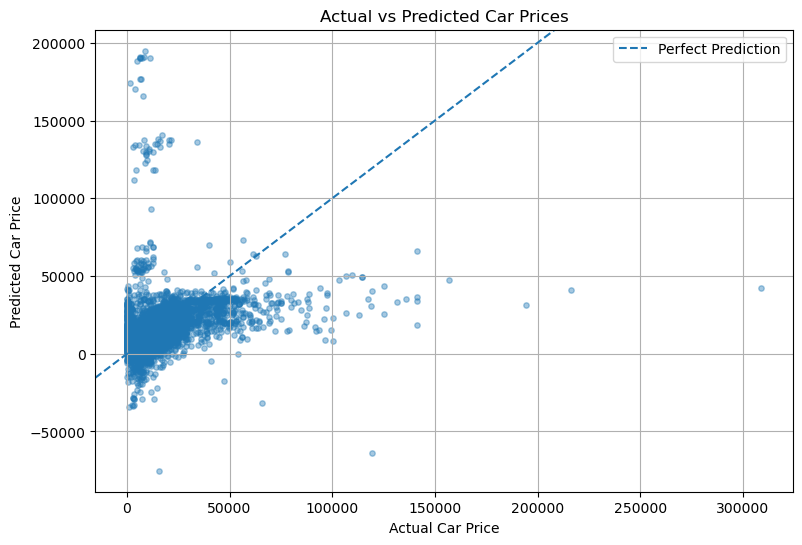

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4,
    s=15
)

plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Actual vs Predicted Car Prices")

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--",
    label="Perfect Prediction"
)

plt.legend()
plt.grid(True)
plt.show()

In [40]:
df = df[df["Price"] > 0].copy()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (18924, 18)


In [41]:
X = df[
    [
        "Levy",
        "Manufacturer",
        "Prod. year",
        "Category",
        "Leather interior",
        "Fuel type",
        "Engine volume",
        "Mileage",
        "Cylinders",
        "Gear box type",
        "Drive wheels",
        "Airbags"
    ]
]

y = df["Price"]

In [42]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Encoded data shape:", X_encoded.shape)

Encoded data shape: (18924, 92)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15139, 92)
Testing data: (3785, 92)


In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model retrained successfully!")

Model retrained successfully!


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("New Model Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

New Model Evaluation:
MAE: 12900.690661697909
MSE: 527292719.5908979
R² Score: -0.5229629124636443


In [46]:
import numpy as np

# Price ka log transformation
y_log = np.log1p(y)

print(y_log.head())

0    9.497697
1    9.718482
2    9.044050
3    8.190909
4    9.369649
Name: Price, dtype: float64


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_log,
    test_size=0.2,
    random_state=42
)

In [48]:
log_model = LinearRegression()

log_model.fit(X_train, y_train)

print("Log-transformed model trained!")

Log-transformed model trained!


In [49]:
y_log_pred = log_model.predict(X_test)

# Log predictions ko original price scale par convert karna
y_pred_original = np.expm1(y_log_pred)

# Actual prices bhi original scale par lao
y_test_original = np.expm1(y_test)

In [50]:
mae_log = mean_absolute_error(y_test_original, y_pred_original)
mse_log = mean_squared_error(y_test_original, y_pred_original)
r2_log = r2_score(y_test_original, y_pred_original)

print("Log Model Evaluation:")
print("MAE:", mae_log)
print("MSE:", mse_log)
print("R² Score:", r2_log)

Log Model Evaluation:
MAE: 10232.933781003236
MSE: 322266626.42302173
R² Score: 0.06920747863193


In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [53]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [56]:
rf_pred = rf_model.predict(X_test)

print("First 10 Predictions:")
print(rf_pred[:10])

First 10 Predictions:
[15757.62   1071.77  29415.32   6326.67  12580.    44237.84  11642.209
 15778.69   6772.77   1372.96 ]


In [57]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation:")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Random Forest Evaluation:
MAE: 5950.689512040509
MSE: 6713915654.750731
R² Score: -18.391590590379423


In [58]:
y_original = df["Price"]

In [59]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_encoded,
    y_original,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest retrained successfully!")

Random Forest retrained successfully!


In [61]:
rf_pred = rf_model.predict(X_test_rf)

print("First 10 predictions:")
print(rf_pred[:10])

First 10 predictions:
[15757.62   1071.77  29415.32   6326.67  12580.    44237.84  11642.209
 15778.69   6772.77   1372.96 ]


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test_rf, rf_pred)
rf_mse = mean_squared_error(y_test_rf, rf_pred)
rf_r2 = r2_score(y_test_rf, rf_pred)

print("Correct Random Forest Evaluation:")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Correct Random Forest Evaluation:
MAE: 5950.689512040509
MSE: 6713915654.750731
R² Score: -18.391590590379423


In [63]:
print(df["Price"].describe())

count    1.892400e+04
mean     1.858744e+04
std      1.921356e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.206300e+04
max      2.630750e+07
Name: Price, dtype: float64


In [64]:
print(
    df[["Price", "Manufacturer", "Model"]]
    .sort_values("Price", ascending=False)
    .head(20)
)

          Price   Manufacturer                    Model
16983  26307500           OPEL                    Combo
8541     872946    LAMBORGHINI                     Urus
1225     627220  MERCEDES-BENZ           G 65 AMG 63AMG
5008     308906        PORSCHE                      911
9367     297930  MERCEDES-BENZ                 AMG GT S
14839    297930     LAND ROVER        Range Rover Vogue
7749     288521            BMW  M5 Машина в максимально
10759    260296          LEXUS                   LX 570
5840     254024  MERCEDES-BENZ            GLE 400 A M G
15283    250574  MERCEDES-BENZ                  GLE 400
7283     228935  MERCEDES-BENZ               GLE 63 AMG
2283     219527        BENTLEY           Continental GT
7353     216391  MERCEDES-BENZ         G 65 AMG G63 AMG
1145     194438  MERCEDES-BENZ                    G 350
13328    193184  MERCEDES-BENZ   GLE 400 Coupe, AMG Kit
4722     175622        BENTLEY                 Mulsanne
2768     172486         TOYOTA             Land 

In [65]:
print(
    df[["Price", "Manufacturer", "Model"]]
    .sort_values("Price", ascending=True)
    .head(20)
)

       Price   Manufacturer     Model
7815       1           OPEL     Astra
16992      1      CHEVROLET   Lacetti
753        3         NISSAN   X-Terra
15347      3            BMW       525
9730       3            KIA  Sportage
10885      3      CHEVROLET     Cruze
4776       3     VOLKSWAGEN     Jetta
17596      3        HYUNDAI    Sonata
5890       3  MERCEDES-BENZ   CLK 230
11636      3  MERCEDES-BENZ     C 220
14492      3     VOLKSWAGEN     Jetta
8993       3         TOYOTA   Prius C
4958       3     VOLKSWAGEN     Jetta
13419      3         TOYOTA   Prius C
14642      3        PORSCHE  Panamera
221        3        HYUNDAI   Elantra
7276       3  MERCEDES-BENZ  G 55 AMG
8454       6          DODGE      Neon
18575      6  MERCEDES-BENZ       200
1164       6         TOYOTA   Prius C


In [66]:
print("Actual price range:")
print(y_test_rf.min(), y_test_rf.max())

print("\nPredicted price range:")
print(rf_pred.min(), rf_pred.max())

Actual price range:
3 308906

Predicted price range:
30.0 5002392.5


In [67]:
comparison_rf = pd.DataFrame({
    "Actual Price": y_test_rf.values,
    "Predicted Price": rf_pred
})

comparison_rf.head(20)

,Actual Price,Predicted Price
0,11604,15757.620000
1,470,1071.770000
2,20162,29415.320000
3,7527,6326.670000
4,18817,12580.000000
5,44003,44237.840000
6,21326,11642.209000
7,15681,15778.690000
8,6899,6772.770000
9,1333,1372.960000


In [70]:
price_threshold = df["Price"].quantile(0.99)

print("99th Percentile Price:", price_threshold)

99th Percentile Price: 84675.0


In [71]:
df_clean = df[
    (df["Price"] > 0) &
    (df["Price"] <= price_threshold)
].copy()

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (18924, 18)
After outlier removal: (18741, 18)


In [72]:
print(df_clean["Price"].describe())

count    18741.000000
mean     16137.508671
std      14774.678995
min          1.000000
25%       5175.000000
50%      12880.000000
75%      21950.000000
max      84675.000000
Name: Price, dtype: float64


In [73]:
X_clean = df_clean[
    [
        "Levy",
        "Manufacturer",
        "Prod. year",
        "Category",
        "Leather interior",
        "Fuel type",
        "Engine volume",
        "Mileage",
        "Cylinders",
        "Gear box type",
        "Drive wheels",
        "Airbags"
    ]
]

y_clean = df_clean["Price"]

print("Features shape:", X_clean.shape)
print("Target shape:", y_clean.shape)

Features shape: (18741, 12)
Target shape: (18741,)


In [74]:
X_clean_encoded = pd.get_dummies(
    X_clean,
    drop_first=True,
    dtype=int
)

print("Encoded shape:", X_clean_encoded.shape)

Encoded shape: (18741, 90)


In [75]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean_encoded,
    y_clean,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train_clean.shape)
print("Testing shape:", X_test_clean.shape)

Training shape: (14992, 90)
Testing shape: (3749, 90)


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_clean_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [77]:
rf_clean_model.fit(
    X_train_clean,
    y_train_clean
)

print("Random Forest trained on cleaned data!")

Random Forest trained on cleaned data!


In [78]:
rf_clean_pred = rf_clean_model.predict(X_test_clean)

print("First 10 predictions:")
print(rf_clean_pred[:10])

First 10 predictions:
[12272.79       21765.62        9232.93       22140.73
 24794.7         7617.26       13937.69       17593.53001138
 11972.05        5018.        ]


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_clean_mae = mean_absolute_error(
    y_test_clean,
    rf_clean_pred
)

rf_clean_mse = mean_squared_error(
    y_test_clean,
    rf_clean_pred
)

rf_clean_r2 = r2_score(
    y_test_clean,
    rf_clean_pred
)

print("Random Forest After Outlier Removal:")
print("MAE:", rf_clean_mae)
print("MSE:", rf_clean_mse)
print("R² Score:", rf_clean_r2)

Random Forest After Outlier Removal:
MAE: 3934.443302177184
MSE: 48182686.011713386
R² Score: 0.7728201386888507


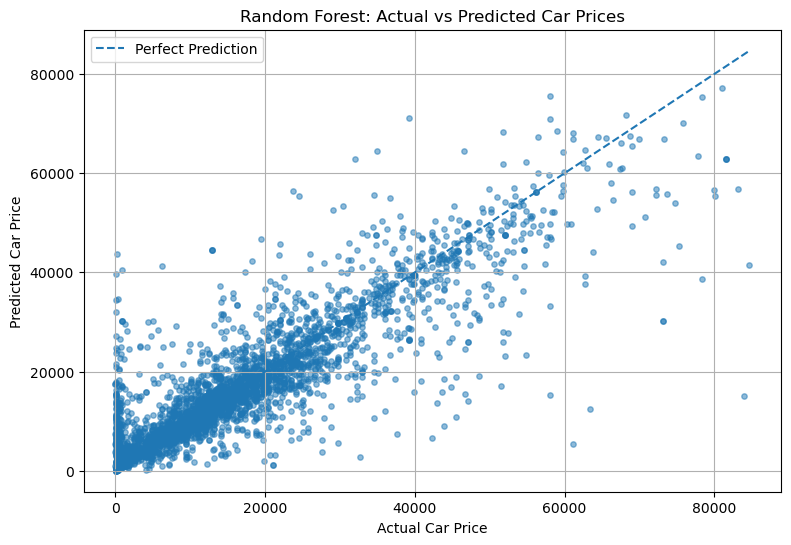

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_clean,
    rf_clean_pred,
    alpha=0.5,
    s=15
)

# Perfect prediction line
min_value = min(y_test_clean.min(), rf_clean_pred.min())
max_value = max(y_test_clean.max(), rf_clean_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("Random Forest: Actual vs Predicted Car Prices")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
feature_importance = pd.DataFrame({
    "Feature": X_clean_encoded.columns,
    "Importance": rf_clean_model.feature_importances_
})

In [82]:
top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

print(top_features)

                       Feature  Importance
1                   Prod. year    0.210059
3                      Mileage    0.133270
5                      Airbags    0.118523
2                Engine volume    0.104788
79            Fuel type_Diesel    0.075838
0                         Levy    0.074762
86     Gear box type_Tiptronic    0.069570
88          Drive wheels_Front    0.033055
78        Leather interior_Yes    0.019085
83            Fuel type_Petrol    0.015858
71               Category_Jeep    0.014782
4                    Cylinders    0.014075
76              Category_Sedan    0.013957
61         Manufacturer_TOYOTA    0.010819
39  Manufacturer_MERCEDES-BENZ    0.010731


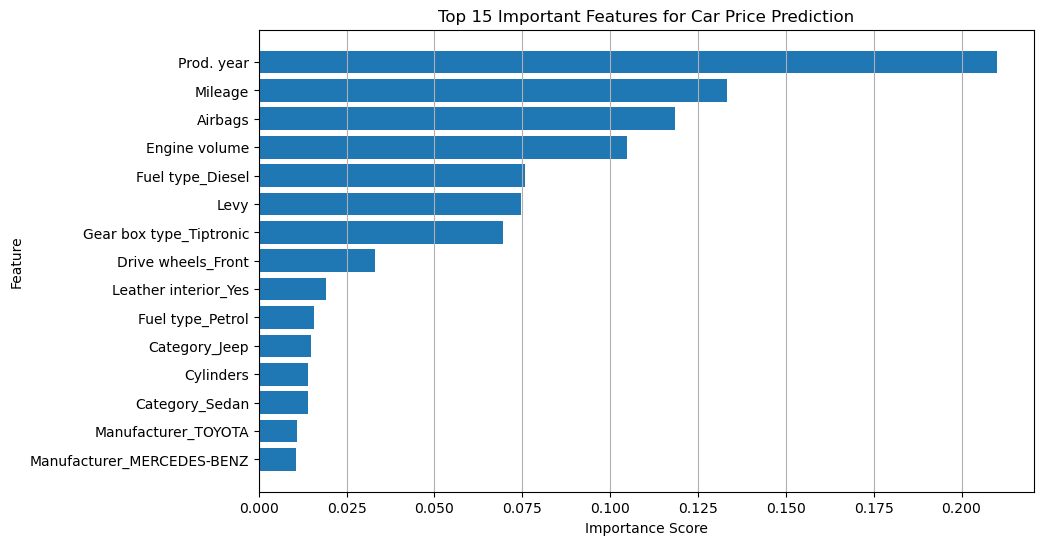

In [83]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Important Features for Car Price Prediction")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [84]:
comparison_models = pd.DataFrame({
    "Model": [
        "Original Linear Regression",
        "Log Linear Regression",
        "Random Forest After Cleaning"
    ],
    "R2 Score": [
        -0.52296,
        0.06921,
        0.77282
    ],
    "MAE": [
        12900.69,
        10232.93,
        3934.44
    ]
})

comparison_models

,Model,R2 Score,MAE
0,Original Linear Regression,-0.52296,12900.69
1,Log Linear Regression,0.06921,10232.93
2,Random Forest After Cleaning,0.77282,3934.44


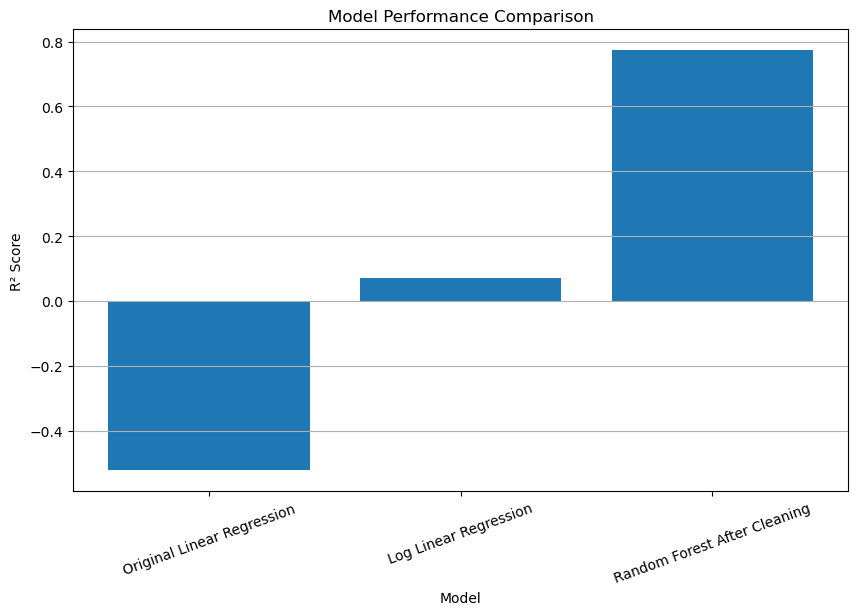

In [85]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_models["Model"],
    comparison_models["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

In [86]:
import joblib

joblib.dump(rf_clean_model, "car_price_random_forest.pkl")
joblib.dump(X_clean_encoded.columns.tolist(), "car_price_features.pkl")

print("Model and features saved successfully!")

Model and features saved successfully!


In [87]:
import os

print(os.listdir())

['  problem.ipynb', '.anaconda', '.android', '.cache', '.claude', '.claude.json', '.conda', '.config', '.copilot', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.omniroute', '.streamlit', '.viminfo', '.virtual_documents', '.vscode', '.vscode-shared', '.wsa-pacman', 'a.txt', 'AppData', 'Application Data', 'b.txt', 'car_price_features.pkl', 'car_price_prediction.ipynb', 'car_price_random_forest.pkl', 'Contacts', 'Cookies', 'CrossDevice', 'Documents', 'Downloads', 'Favorites', 'FertiLink', 'Figure_1.png', 'Figure_11.png', 'Figure_12.png', 'Figure_2.png', 'Figure_3.png', 'Figure_4.png', 'Figure_5.png', 'Figure_6.png', 'Figure_7.png', 'Figure_8.png', 'Figure_9.png', 'linear_regression.ipynb', 'Links', 'Local Settings', 'log.txt', 'ML.py', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1c9be92d-909f-11ef-9f6e-00155d981787}.TM.blf', 'NTUSER.DAT{1c9be92d-909f-